# 02. Формат партитуры `score.json`

Партитура — это **статика**, она известна заранее. Хранится в JSON. Все трекеры (`OLTW`, `HMM`, `HSMM`, `Hybrid`) принимают её на вход в одном и том же формате.

Схема одного `score.json`:

```jsonc
{
  "piece_name": "...",
  "notes": [
    {
      "index": 0,                       // порядковый номер state
      "pitch": 60,                      // ИЛИ
      "pitches": [60, 64, 67],          // аккорд (chord)
      "nominal_onset": 2.999,           // секунды от начала
      "nominal_duration": 1.499         // секунды
    },
    ...
  ]
}
```

**Один элемент `notes` = одно скрытое состояние HMM/HSMM**, не одна физическая нота. Если в момент 1.234 с зазвучали 3 ноты в течение 30 мс — это **один state** с `pitches: [60, 64, 67]`. Этот процесс кластеризации делает `midi_to_score.py` (параметр `chord_epsilon=0.03`).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

## 1. Простой случай: `ideal.json`

Восемь нот гаммы C-мажор, каждая по 0.5 секунды. `pitch` — скалярное поле, аккордов нет.

In [3]:
ideal_score = json.loads((PROJECT_ROOT / "generated_dataset" / "ideal.json").read_text(encoding="utf-8"))

print("piece_name:", ideal_score["piece_name"])
print("states    :", len(ideal_score["notes"]))
print()

for note in ideal_score["notes"][:5]:
    print(note)

piece_name: ideal
states    : 8

{'index': 0, 'pitch': 60, 'nominal_duration': 0.5}
{'index': 1, 'pitch': 62, 'nominal_duration': 0.5}
{'index': 2, 'pitch': 64, 'nominal_duration': 0.5}
{'index': 3, 'pitch': 65, 'nominal_duration': 0.5}
{'index': 4, 'pitch': 67, 'nominal_duration': 0.5}


## 2. Реальный случай: `rach_solo`

Полная партитура Рахманинова — 3791 state, каждое состояние с `pitches` (аккорды), большой dynamic range.

In [4]:
rach_score = json.loads(
    (PROJECT_ROOT / "midi" / "library" / "rach_solo" / "source" / "source.json").read_text(encoding="utf-8")
)

rach_notes = rach_score["notes"]
print("states:", len(rach_notes))
print("first 3:")
for note in rach_notes[:3]:
    print(note)

states: 3791
first 3:
{'index': 0, 'pitches': [41, 48, 56, 60, 65, 68, 72], 'nominal_onset': 2.999624, 'nominal_duration': 1.499812}
{'index': 1, 'pitches': [29], 'nominal_onset': 4.499436, 'nominal_duration': 1.499812}
{'index': 2, 'pitches': [41, 48, 49, 56, 60, 61, 65, 68, 72], 'nominal_onset': 5.999248, 'nominal_duration': 1.499812}


Объяснение:

- В нотах хранятся словари, в каждом словаре - индекс ноты
- `nominal_onset` — время, в которое должна прозвучать нота согласно партитуре (обычно в секундах от начала произведения).
- `nominal_duration` — длительность ноты по партитуре (обычно в секундах); сколько времени нота должна звучать.

In [ ]:
# Сборка таблицы для удобного анализа.
rows = []
for note in rach_notes:
    pitches = note.get("pitches", [note["pitch"]] if "pitch" in note else [])
    rows.append({
        "index": note["index"],
        "onset": note["nominal_onset"],
        "duration": note["nominal_duration"],
        "top_pitch": max(pitches),
        "chord_size": len(pitches),
    })
rach_df = pd.DataFrame(rows)
rach_df.describe().round(3)

,index,onset,duration,top_pitch,chord_size
count,3791.000,3791.000,3791.000,3791.000,3791.000
mean,1895.000,325.145,0.170,67.103,1.887
std,1094.512,182.874,0.653,14.412,1.551
min,0.000,3.000,0.050,24.000,1.000
25%,947.500,163.305,0.091,56.000,1.000
50%,1895.000,334.186,0.125,67.000,1.000
75%,2842.500,458.299,0.167,78.000,2.000
max,3790.000,646.006,31.997,103.000,9.000


## 3. Визуализация партитуры (pitch vs time)

Каждая точка — один state. Высота — самая высокая нота в аккорде.

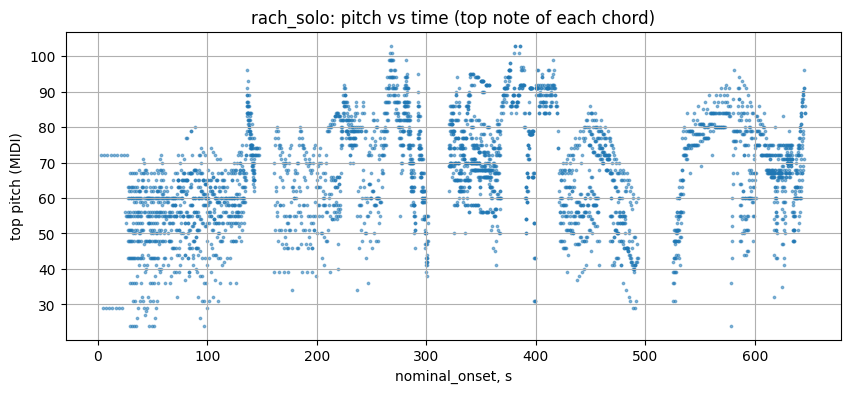

In [6]:
fig, ax = plt.subplots()
ax.scatter(rach_df["onset"], rach_df["top_pitch"], s=3, alpha=0.5)
ax.set_xlabel("nominal_onset, s")
ax.set_ylabel("top pitch (MIDI)")
ax.set_title("rach_solo: pitch vs time (top note of each chord)")
plt.show()

## 4. Распределения длительностей и размеров аккордов

`nominal_duration` нужно HSMM (определяет, когда пора переходить вперёд).  
`chord_size` показывает, насколько партитура полифонична — это нагрузка на эмиссионную модель.

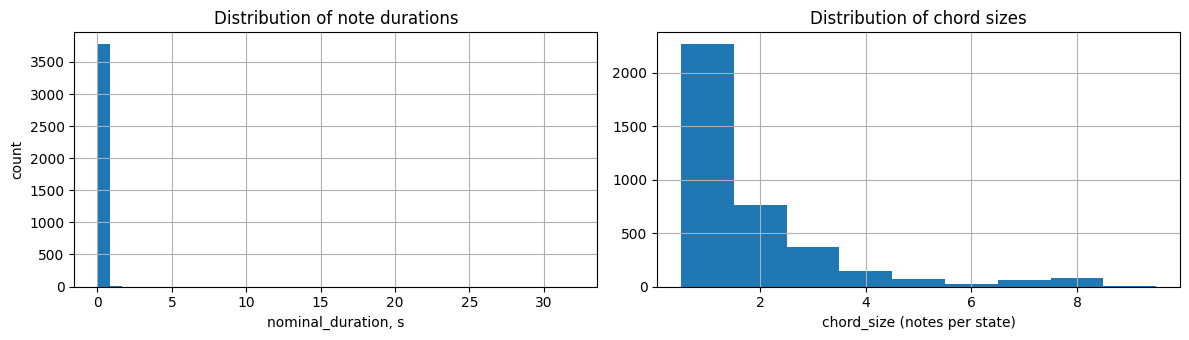

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].hist(rach_df["duration"], bins=40)
axes[0].set_xlabel("nominal_duration, s")
axes[0].set_ylabel("count")
axes[0].set_title("Distribution of note durations")

axes[1].hist(rach_df["chord_size"], bins=range(1, rach_df["chord_size"].max() + 2), align="left")
axes[1].set_xlabel("chord_size (notes per state)")
axes[1].set_title("Distribution of chord sizes")

plt.tight_layout()
plt.show()

## 5. Что отсюда следует для тезисов

- **Эмиссионная модель** должна корректно работать с аккордами (max chord size в `rach_solo` ~ 9 нот). В `hsmm_follower._emission_probabilities` это уже сделано через `nanmin` по chord matrix.
- **Распределение длительностей** не равномерное — много коротких и тяжёлый хвост. Для честного HSMM по Cont 2010 это значит, что параметризовать `p_i(d)` через log-normal надёжнее, чем через Gaussian.
- **Поле `nominal_onset`** даёт нам **карту времени партитуры** — отсюда можно построить `bar_to_index` для UI-фичи «начать с произвольного такта».